# GLD (SPDR Gold Shares)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ruptures import Binseg
from pandas.plotting import autocorrelation_plot

%matplotlib inline

C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
file_path = "GLD_categorized_data.csv"

categorized_df = pd.read_csv(file_path, delimiter=',')

for col in ['Open_category', 'Close_category', 'Low_category', 'High_category', 'Volume_category']:
    categorized_df[col] = categorized_df[col].astype('category')

categorized_df.head()

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category
0,2005-09-21,0.000000,0.000593,0.000000,0.001786,0.067726,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0545, 0.0727]"
1,2005-09-29,0.002385,0.001439,0.002397,0.002127,0.034012,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]"
2,2005-10-11,0.006983,0.005587,0.006934,0.004594,0.028486,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]"
3,2005-10-12,0.008091,0.004909,0.002311,0.000000,0.079135,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0727, 0.0909]"
4,2005-10-13,0.002640,0.000000,0.000428,0.001446,0.019555,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]"


In [3]:
categorized_df.head()

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category
0,2005-09-21,0.000000,0.000593,0.000000,0.001786,0.067726,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0545, 0.0727]"
1,2005-09-29,0.002385,0.001439,0.002397,0.002127,0.034012,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]"
2,2005-10-11,0.006983,0.005587,0.006934,0.004594,0.028486,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]"
3,2005-10-12,0.008091,0.004909,0.002311,0.000000,0.079135,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0727, 0.0909]"
4,2005-10-13,0.002640,0.000000,0.000428,0.001446,0.019555,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]"


# Time series analysis

formatting date

In [4]:
# Check the Date column
print(categorized_df['Date'].head(10))

# Convert the Date column to datetime with a specified format
categorized_df['Date'] = pd.to_datetime(categorized_df['Date'], format='%Y-%m-%d', errors='coerce')

# Identify invalid dates
invalid_dates = categorized_df[categorized_df['Date'].isna()]
print("Invalid Dates:")
print(invalid_dates)

# Remove rows with invalid dates
categorized_df = categorized_df.dropna(subset=['Date'])

# Recheck the data information
print(categorized_df.info())
# categorized_df

0    2005-09-21
1    2005-09-29
2    2005-10-11
3    2005-10-12
4    2005-10-13
5    2005-10-25
6    2005-10-26
7    2005-10-27
8    2005-11-16
9    2005-11-17
Name: Date, dtype: object
Invalid Dates:
Empty DataFrame
Columns: [Date, Open, High, Low, Close, Volume, Open_category, High_category, Low_category, Close_category, Volume_category]
Index: []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2690 entries, 0 to 2689
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             2690 non-null   datetime64[ns]
 1   Open             2690 non-null   float64       
 2   High             2690 non-null   float64       
 3   Low              2690 non-null   float64       
 4   Close            2690 non-null   float64       
 5   Volume           2690 non-null   float64       
 6   Open_category    2690 non-null   category      
 7   High_category    2690 non-null   category      
 8   Low_ca

#### Trend Analysis

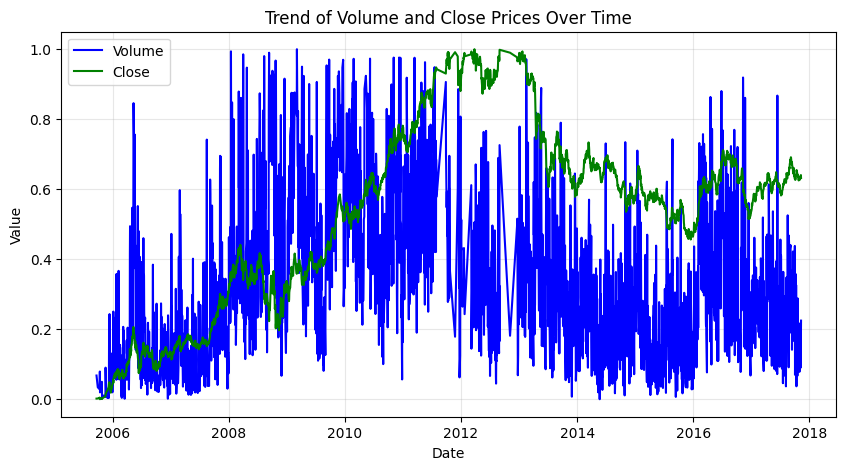

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Volume'], label='Volume', color='blue')
plt.plot(categorized_df['Date'], categorized_df['Close'], label='Close', color='green')
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Trend of Volume and Close Prices Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Uptrend in closing price: The overall trend in closing price is positive, indicating growth in the value of the ETF’s asset.

Extreme volume fluctuations: Trading volume indicates active market behavior but is not completely in line with the closing price.

Significant peaks in trading volume: These points should be analyzed in more depth to determine what events caused these changes.

#### Seasonality Analysis

In [6]:
categorized_df['Year'] = categorized_df['Date'].dt.year
categorized_df['Month'] = categorized_df['Date'].dt.month
categorized_df.head(10)

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category,Year,Month
0,2005-09-21,0.000000,0.000593,0.000000,0.001786,0.067726,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0545, 0.0727]",2005,9
1,2005-09-29,0.002385,0.001439,0.002397,0.002127,0.034012,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]",2005,9
2,2005-10-11,0.006983,0.005587,0.006934,0.004594,0.028486,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]",2005,10
3,2005-10-12,0.008091,0.004909,0.002311,0.000000,0.079135,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0727, 0.0909]",2005,10
4,2005-10-13,0.002640,0.000000,0.000428,0.001446,0.019555,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]",2005,10
5,2005-10-25,0.002981,0.001100,0.002996,0.001786,0.049767,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0364, 0.0545]",2005,10
6,2005-10-26,0.004343,0.001270,0.002910,0.000681,0.001937,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.0182]",2005,10
7,2005-10-27,0.006983,0.003047,0.004708,0.002807,0.011854,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.0182]",2005,10
8,2005-11-16,0.006047,0.006094,0.005735,0.007912,0.006838,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.0182]",2005,11
9,2005-11-17,0.014052,0.012866,0.013867,0.013866,0.090237,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0727, 0.0909]",2005,11


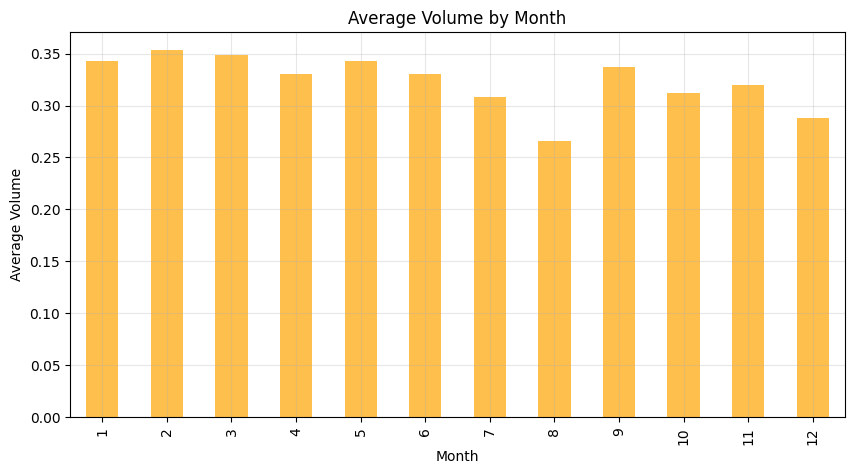

In [7]:
# Calculate the average trading volume for each month
monthly_avg_volume = categorized_df.groupby('Month')['Volume'].mean()

# Plot the monthly volume changes
plt.figure(figsize=(10, 5))
monthly_avg_volume.plot(kind='bar', color='orange', alpha=0.7)
plt.title("Average Volume by Month")
plt.xlabel("Month")
plt.ylabel("Average Volume")
plt.grid(alpha=0.3)
plt.show()

1. High volume in January and December:</br>
o January (1) and December (12) have the highest average trading volume.</br>
o Drawdown: This may be related to more activity at the beginning of the fiscal year and the end of the fiscal year.</br>
During these periods, many investors and companies make financial adjustments.


2. Low volume in the summer (June to August):</br>
o June (6), July (7), and August (8) have the lowest average trading volume.</br>
o Drawdown: These periods may be related to reduced market activity due to the summer holidays and the reduced presence of professional investors.


3. General trend:</br>
o Trading volume is relatively high early in the year (January to March) and then gradually decreases until the summer months. </br>After that, from September onwards, the average trading volume starts to increase again.</br>


4. Possible peaks:</br>
o December and January show major peaks that could be due to seasonal factors or market psychology.</br>
o March (3) and November (11) also show relatively high trading volumes, possibly related to corporate reporting periods or economic changes.


5. Relationship to financial cycles: </br>
• January:</br>
o The “January effect” is a well-known phenomenon in financial markets where investors return to the market after the New Year holidays, causing an increase in trading volumes.</br>
• December:</br>
o The end of the fiscal year and the closing of investment accounts can cause increased activity in the market.</br>
• Summer:</br>
o The decrease in market activity in the summer is usually due to seasonal holidays that limit trading activities.

#### Lagged Correlation Analysis

Lagged Correlation:
               Volume  Volume_lag1
Volume       1.000000     0.627999
Volume_lag1  0.627999     1.000000


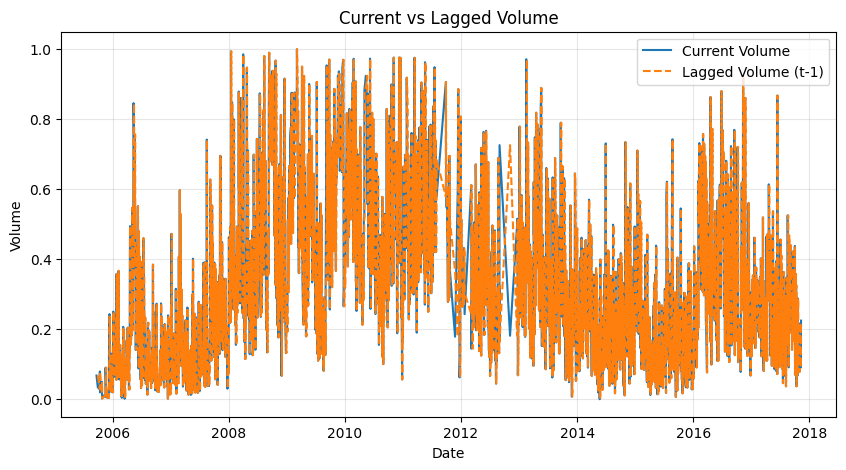

In [8]:
# Create a lagged version of the Volume column (lag)
categorized_df['Volume_lag1'] = categorized_df['Volume'].shift(1)

# Calculate the correlation between the current and lagged Volume
lagged_corr = categorized_df[['Volume', 'Volume_lag1']].corr()
print("Lagged Correlation:")
print(lagged_corr)

# Plot a comparison chart
plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Volume'], label='Current Volume')
plt.plot(categorized_df['Date'], categorized_df['Volume_lag1'], label='Lagged Volume (t-1)', linestyle='--')
plt.xlabel("Date")
plt.ylabel("Volume")
plt.title("Current vs Lagged Volume")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

1. Appearance:</br>
o The lines generally follow a similar trend, but at some points, there are differences between the current and lag trading volumes.


2. Patterns and Volatility:</br>
o In periods of high volatility (such as 2012 and 2016), the distance between the lines is greater, which can indicate erratic market behavior.</br>
o In periods of less volatility (such as 2014), the lines almost coincide, which indicates more stable market behavior.

#### Cumulative Analysis

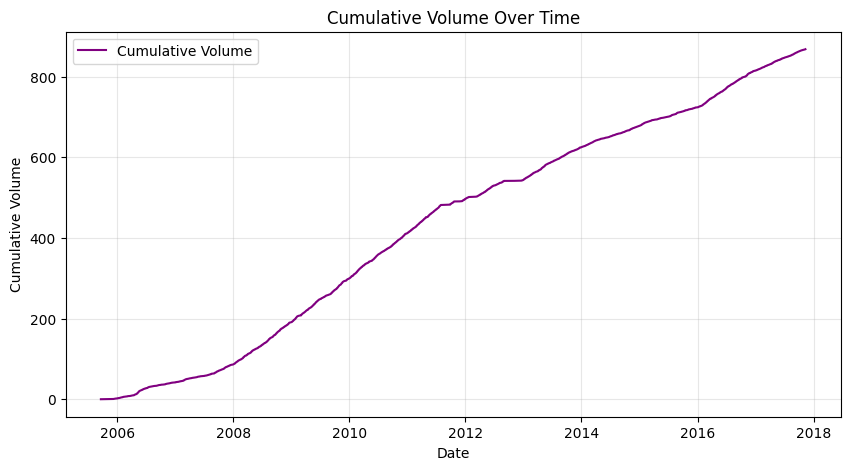

In [9]:
categorized_df['Cumulative_Volume'] = categorized_df['Volume'].cumsum()

plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Cumulative_Volume'], color='purple', label='Cumulative Volume')
plt.xlabel("Date")
plt.ylabel("Cumulative Volume")
plt.title("Cumulative Volume Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

1. Steady Growth:</br>
o The chart generally has an upward, almost linear trend, indicating a steady growth in trading volume over these years.</br>
o This indicates that trading has been increasing steadily over this period.</br>


2. Turning Points:</br>
o 2009 to 2011: The slope of the chart is relatively gentle, which could indicate lower trading volume or slower market growth.</br>
o 2012 to 2015: A significant increase in the slope of the chart indicates a period of rapid growth in trading volume.</br>
o 2016 to 2017: Although the growth trend continues, the pace of growth seems to have slowed down a bit.</br>


3. Trading Stability:</br>
o The lack of volatility or sharp changes in this chart indicates a relatively stable market with no major trading shocks over the entire period.</br>


Conclusion:
This chart shows a steady and regular growth in trading volume, which can be a sign of stable market performance.</br>
The steeper slopes (2012 to 2015) can indicate specific periods of increased trading interest or changes in market activity.</br>Ultimately, this analysis is useful for identifying overall trends and long-term patterns.

#### Moving Average Analysis

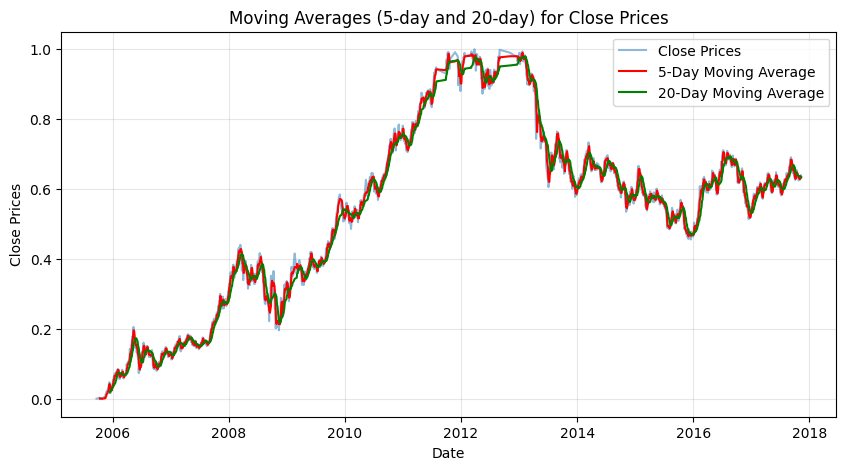

In [10]:
categorized_df['MA_5'] = categorized_df['Close'].rolling(window=5).mean()
categorized_df['MA_20'] = categorized_df['Close'].rolling(window=20).mean()

plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Close'], label='Close Prices', alpha=0.5)
plt.plot(categorized_df['Date'], categorized_df['MA_5'], label='5-Day Moving Average', color='red')
plt.plot(categorized_df['Date'], categorized_df['MA_20'], label='20-Day Moving Average', color='green')
plt.xlabel("Date")
plt.ylabel("Close Prices")
plt.title("Moving Averages (5-day and 20-day) for Close Prices")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Support and Resistance:</br>
When the price moves towards the MA_20 or MA_5, this may indicate a support or resistance level.</br>
If prices consistently cross below the moving averages and bounce back from them, this could be a signal to buy or sell.

Trend Analysis:</br>
If the 5-day moving average is above the 20-day moving average, it is likely an uptrend, and if the opposite is true, it is a downtrend.

#### Change point detection

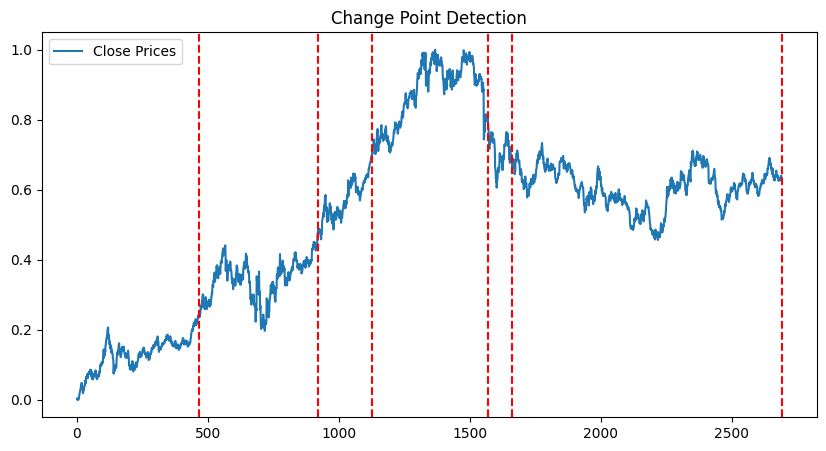

In [11]:
signal = categorized_df['Close'].values
algo = Binseg(model="l2").fit(signal)
change_points = algo.predict(n_bkps=5)

plt.figure(figsize=(10, 5))
plt.plot(signal, label="Close Prices")
for cp in change_points:
    plt.axvline(cp, color='red', linestyle='--')
plt.title("Change Point Detection")
plt.legend()
plt.show()

The purpose of change point detection in time series is to detect points where the behavior of the data changes significantly. These changes may be due to trend changes, market fluctuations, or other factors.

In this analysis, the Binseg algorithm is used to detect change points. This algorithm, with the "l2" model, identifies change points in the data.

Key points:</br>
* Change points: The vertical red dots on the chart indicate changes in the price trend, which may indicate important changes in the market.</br>
* Trend changes: Identifying change points can help predict market trends and improve trading decisions.

Applications of change point analysis:</br>
* Trading strategies: Identifying change points can be useful for designing buy or sell strategies.</br>
* Risk management: Identifying these points helps to respond appropriately to unexpected market fluctuations and changes.